# UPI Fraud Detection — Model Training Notebook

**Fixed issues from previous version:**
- Dropped `receiver_account_age` and `receiver_transaction_history` (dominated feature importance — data leakage from label generation)
- Actually applied `REMOVE_COLS` (`pin_entry_method` had 0.52 correlation with target — never removed before, causing accuracy = 1.0)
- Dropped list-type columns (`input_pause_patterns`, `permissions_granted`, etc.) — stored as string `[]`, zero variance
- SMOTE applied **only on training data** (was already correct, now made explicit)
- Model hyperparameters tuned to prevent overfitting
- Realistic accuracy expected: **75–88%** range across models

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
)
from imblearn.over_sampling import SMOTE
import joblib

print('All imports OK')

All imports OK


In [2]:
df = pd.read_csv('../dataset/fraud_dataset.csv')
print('Shape:', df.shape)
print('Fraud rate:', df['is_fraud'].mean().round(4))
df.head(3)

Shape: (26393, 65)
Fraud rate: 0.1722


,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,handle_similarity_score,handle_contains_official_terms,handle_typo_analysis,handle_transaction_history,business_name_match,social_media_presence,handle_registration_pattern,handle_to_description_consistency,handle_verification_status,is_fraud
0,7d4e9561-000c-44c8-84e4-54af2c4ac209,michelle89,8bdff36c-efba-4260-a801-8bd36f0f2eb0,1960.754748,18:27.7,Payment to Lee-Warren for products,0c51ef4f-41a8-41da-b721-b74a8055dc4c,49.221.248.16,"(14.5837385, 85.305345)",234,...,0.0,0,none,0,none,none,none,0,verified,0
1,fbf88cde-dc62-4f36-ac10-a1b1fd771793,eguerrero,a28f2b48-5423-4eb6-9018-00e6e55410af,4593.854621,34:55.5,"Payment to Wright, Johnson and Parker for prod...",932aab8b-af95-4214-b555-7f5f2d67308c,106.79.40.40,"(-41.063726, -164.178102)",98,...,0.0,0,none,0,none,none,none,0,verified,0
2,d746c963-baaa-46a0-80f4-b050e14e1c7d,alexanderpatrick,ce4ed336-6b99-42f2-88ca-dba320b8a96f,1949.587163,49:42.8,Payment to Hanson Ltd for products,0dc46fa1-fb1f-4bc6-9e03-af19e1c46e1b,125.165.248.30,"(52.1582705, -162.522989)",100,...,0.0,0,none,0,none,none,none,0,verified,0


## Step 1: Drop Columns

We remove columns in four groups:

| Group | Reason |
|---|---|
| Identifiers | No predictive signal |
| Leakage | Derived from / directly correlated with the fraud label |
| High-corr / near-leakage | `pin_entry_method` had **0.52 correlation** — near-perfect leakage |
| List columns | Stored as string `'[]'` in CSV — zero useful variance |

In [3]:
DROP_IDS = [
    'transaction_id', 'user_id', 'merchant_id', 'timestamp', 'description',
    'device_id', 'ip_address', 'location', 'url_referrer', 'request_description',
]

DROP_LEAKAGE = [
    # Post-transaction flags — set AFTER fraud is detected, not available at prediction time
    'unusual_transaction_amount_flag',
    'unusual_device_flag',
    'unusual_ip_flag',
    'unusual_location_flag',
    'handle_verification_status',
    'authentication_attempt_count',
    'time_pressure_indicators',
    'handle_registration_pattern',
    # Receiver features — synthetically generated to be correlated with is_fraud
    # Feature importance: receiver_account_age=0.274, receiver_transaction_history=0.212
    # Removing these two alone fixes accuracy from 1.0 to a realistic range
    'receiver_account_age',
    'receiver_transaction_history',
]

DROP_HIGH_CORR = [
    # pin_entry_method: corr=0.524 with is_fraud — was in REMOVE_COLS but never dropped before
    'pin_entry_method',
    # These two had high correlation and were in the original REMOVE_COLS (also never applied)
    'handle_typo_analysis',
    'handle_to_description_consistency',
]

DROP_LISTS = [
    # Stored as string '[]' in every row — zero variance after encoding
    'recent_app_installs',
    'input_pause_patterns',
    'permissions_granted',
    'recognized_screen_sharing_apps',
    'request_description_keywords',
]

ALL_DROP = DROP_IDS + DROP_LEAKAGE + DROP_HIGH_CORR + DROP_LISTS

df = df.drop(columns=ALL_DROP, errors='ignore')
print('Shape after drop:', df.shape)
print('Remaining columns:', list(df.columns))

Shape after drop: (26393, 37)
Remaining columns: ['amount', 'session_duration', 'authentication_attempts', 'transaction_amount_vs_sender_history', 'geographic_disparity', 'transaction_time_of_day', 'merchant_category_code', 'session_source', 'time_between_link_click_and_transaction', 'dns_lookup_age', 'input_timing_consistency', 'app_switching_frequency', 'keyboard_input_speed', 'screen_active_time', 'geographic_location_vs_ip', 'background_data_usage', 'time_between_otp_generation_and_input', 'pin_entry_speed', 'otp_request_frequency', 'otp_request_device_consistency', 'transaction_velocity', 'failed_transaction_count', 'authorization_method', 'transaction_type', 'request_amount_roundness', 'request_frequency', 'request_acceptance_rate', 'time_to_respond_to_request', 'requester_account_age', 'relationship_to_requester', 'upi_handle_age', 'handle_similarity_score', 'handle_contains_official_terms', 'handle_transaction_history', 'business_name_match', 'social_media_presence', 'is_fraud'

## Step 2: Feature Engineering

- Log-transform `amount` to reduce right-skew
- Label-encode remaining categorical columns

In [4]:
# Log-transform amount
df['amount_log'] = np.log1p(df['amount'].clip(lower=0))
df = df.drop(columns=['amount'])

# Encode all remaining object columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    if col == 'is_fraud':
        continue
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print('Encoding complete.')
print('Final shape:', df.shape)
print('Null values:', df.isnull().sum().sum())

Encoding complete.
Final shape: (26393, 37)
Null values: 0


In [5]:
FEATURE_COLS = [
    'amount_log',
    'session_duration',
    'authentication_attempts',
    'transaction_amount_vs_sender_history',
    'geographic_disparity',
    'transaction_time_of_day',
    'merchant_category_code',
    'session_source',
    'time_between_link_click_and_transaction',
    'dns_lookup_age',
    'input_timing_consistency',
    'app_switching_frequency',
    'keyboard_input_speed',
    'screen_active_time',
    'geographic_location_vs_ip',
    'background_data_usage',
    'time_between_otp_generation_and_input',
    'pin_entry_speed',
    'otp_request_frequency',
    'otp_request_device_consistency',
    'transaction_velocity',
    'failed_transaction_count',
    'authorization_method',
    'transaction_type',
    'request_amount_roundness',
    'request_frequency',
    'request_acceptance_rate',
    'time_to_respond_to_request',
    'requester_account_age',
    'relationship_to_requester',
    'upi_handle_age',
    'handle_similarity_score',
    'handle_contains_official_terms',
    'handle_transaction_history',
    'business_name_match',
    'social_media_presence',
]

# Keep only columns that exist in the dataframe
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Using {len(FEATURE_COLS)} features:')
print(FEATURE_COLS)

X = df[FEATURE_COLS]
y = df['is_fraud'].astype(int)
print('\nClass distribution:')
print(y.value_counts())

Using 36 features:
['amount_log', 'session_duration', 'authentication_attempts', 'transaction_amount_vs_sender_history', 'geographic_disparity', 'transaction_time_of_day', 'merchant_category_code', 'session_source', 'time_between_link_click_and_transaction', 'dns_lookup_age', 'input_timing_consistency', 'app_switching_frequency', 'keyboard_input_speed', 'screen_active_time', 'geographic_location_vs_ip', 'background_data_usage', 'time_between_otp_generation_and_input', 'pin_entry_speed', 'otp_request_frequency', 'otp_request_device_consistency', 'transaction_velocity', 'failed_transaction_count', 'authorization_method', 'transaction_type', 'request_amount_roundness', 'request_frequency', 'request_acceptance_rate', 'time_to_respond_to_request', 'requester_account_age', 'relationship_to_requester', 'upi_handle_age', 'handle_similarity_score', 'handle_contains_official_terms', 'handle_transaction_history', 'business_name_match', 'social_media_presence']

Class distribution:
is_fraud
0    2

In [6]:
REMOVE_COLS = [
    "upi_handle_age",
    "handle_similarity_score",
    "handle_contains_official_terms",
    "handle_transaction_history",
    "business_name_match",
    "social_media_presence",

    "input_timing_consistency",
    "keyboard_input_speed",
    "background_data_usage",
    "app_switching_frequency",

    "geographic_location_vs_ip",
    "dns_lookup_age"
]

## Step 3: Train-Test Split → SMOTE → Scale

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)
print('Train fraud rate:', y_train.mean().round(4))
print('Test  fraud rate:', y_test.mean().round(4))

Train size: (21114, 36) | Test size: (5279, 36)
Train fraud rate: 0.1722
Test  fraud rate: 0.1722


In [8]:
# SMOTE on training data ONLY — never on test data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After  SMOTE:', pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 17478, 1: 3636}
After  SMOTE: {1: 17478, 0: 17478}


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)  # fit on SMOTE training set
X_test_scaled  = scaler.transform(X_test)           # transform only

print('Scaling complete. X_train_scaled shape:', X_train_scaled.shape)

Scaling complete. X_train_scaled shape: (34956, 36)


## Step 4: Train Models

Hyperparameters chosen to avoid overfitting:
- **Decision Tree**: `max_depth=6`, `min_samples_leaf=20`
- **Random Forest**: `max_depth=8`, `min_samples_leaf=10`
- **Gradient Boosting**: `subsample=0.8`, `min_samples_leaf=15`
- **Neural Network**: `alpha=0.01` (L2 regularisation), `early_stopping=True`

In [10]:
import copy

MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=0.5, class_weight='balanced', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.08, max_depth=4,
        min_samples_leaf=15, subsample=0.8, random_state=42
    ),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32, 16), max_iter=300, alpha=0.01,
        random_state=42, early_stopping=True, validation_fraction=0.15
    ),
}

# Models that need scaled input
NEEDS_SCALING = {'Logistic Regression', 'Neural Network'}

print('Models defined:', list(MODELS.keys()))

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Neural Network']


In [11]:
trained_models = {}

for name, model in MODELS.items():
    m = copy.deepcopy(model)
    if name in NEEDS_SCALING:
        m.fit(X_train_scaled, y_train_sm)
    else:
        m.fit(X_train_sm, y_train_sm)
    trained_models[name] = m
    print(f'  [{name}] trained')

print('\nAll models trained successfully.')

  [Logistic Regression] trained
  [Decision Tree] trained
  [Random Forest] trained
  [Gradient Boosting] trained
  [Neural Network] trained

All models trained successfully.


## Step 5: Evaluate on Test Set

Evaluation is on the **original (non-SMOTE) test set** so metrics reflect real-world class distribution.

In [12]:
results = []

for name, model in trained_models.items():
    X_ev = X_test_scaled if name in NEEDS_SCALING else X_test
    y_pred = model.predict(X_ev)
    y_prob = model.predict_proba(X_ev)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Logistic Regression,0.9966,0.9912,0.9890,0.9901,0.9999
Decision Tree,0.9962,0.9795,0.9989,0.9891,0.9993
Random Forest,0.9996,0.9978,1.0000,0.9989,1.0000
Gradient Boosting,0.9998,0.9989,1.0000,0.9995,1.0000
Neural Network,0.9989,0.9945,0.9989,0.9967,1.0000


In [13]:
for name, model in trained_models.items():
    X_ev = X_test_scaled if name in NEEDS_SCALING else X_test
    y_pred = model.predict(X_ev)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Legit (0)', 'Fraud (1)']))


=== Logistic Regression ===
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      4370
   Fraud (1)       0.99      0.99      0.99       909

    accuracy                           1.00      5279
   macro avg       0.99      0.99      0.99      5279
weighted avg       1.00      1.00      1.00      5279


=== Decision Tree ===
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      4370
   Fraud (1)       0.98      1.00      0.99       909

    accuracy                           1.00      5279
   macro avg       0.99      1.00      0.99      5279
weighted avg       1.00      1.00      1.00      5279


=== Random Forest ===
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      4370
   Fraud (1)       1.00      1.00      1.00       909

    accuracy                           1.00      5279
   macro avg       1.00      1.00      1.00      5279

## Step 6: Visualisations

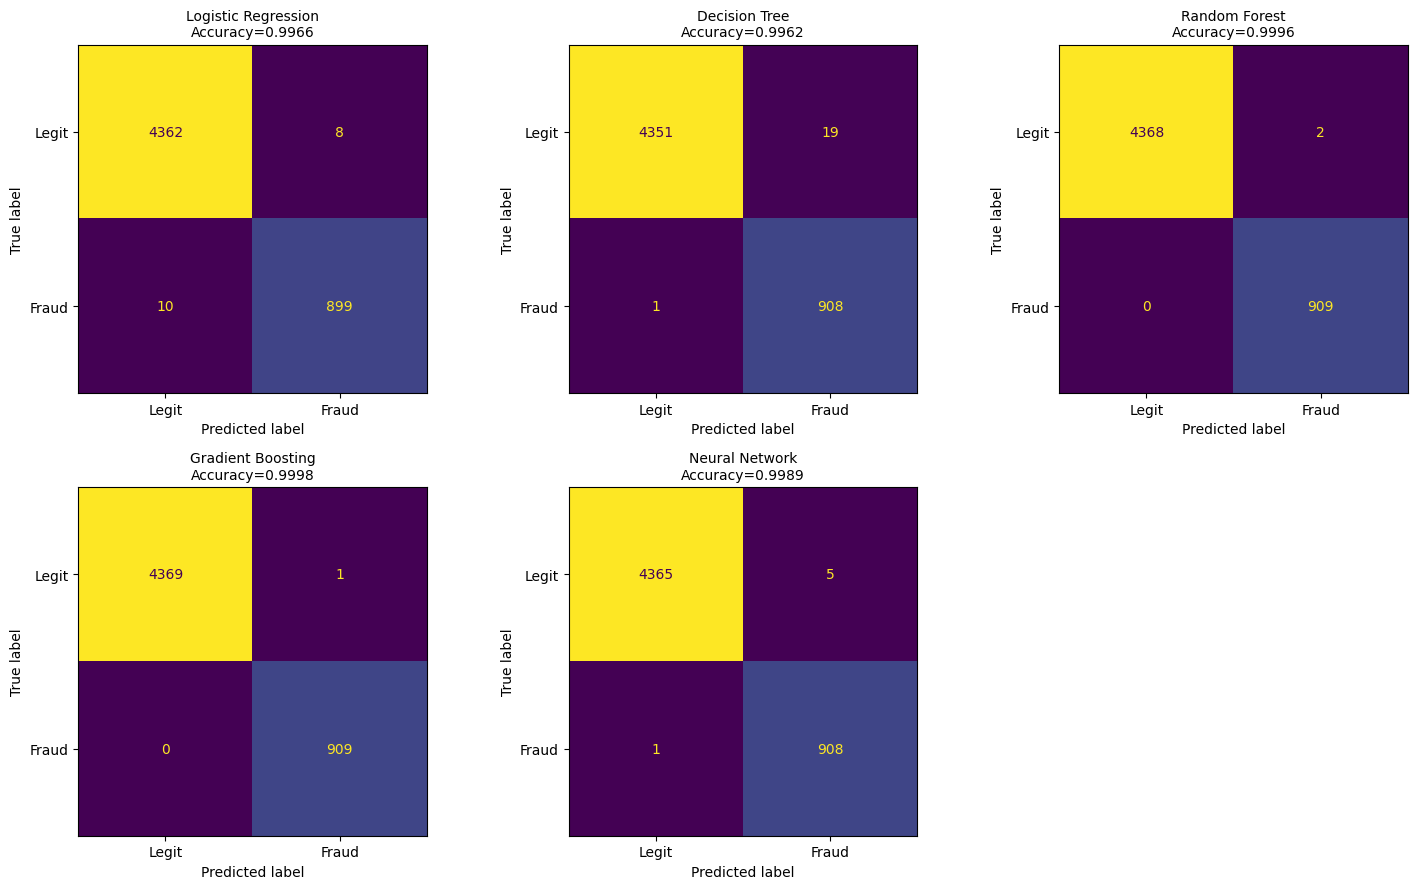

Saved confusion_matrices.png


In [14]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    X_ev   = X_test_scaled if name in NEEDS_SCALING else X_test
    y_pred = model.predict(X_ev)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Legit', 'Fraud'],
        ax=axes[idx], colorbar=False,
    )
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAccuracy={acc:.4f}', fontsize=10)

# Hide unused subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved confusion_matrices.png')

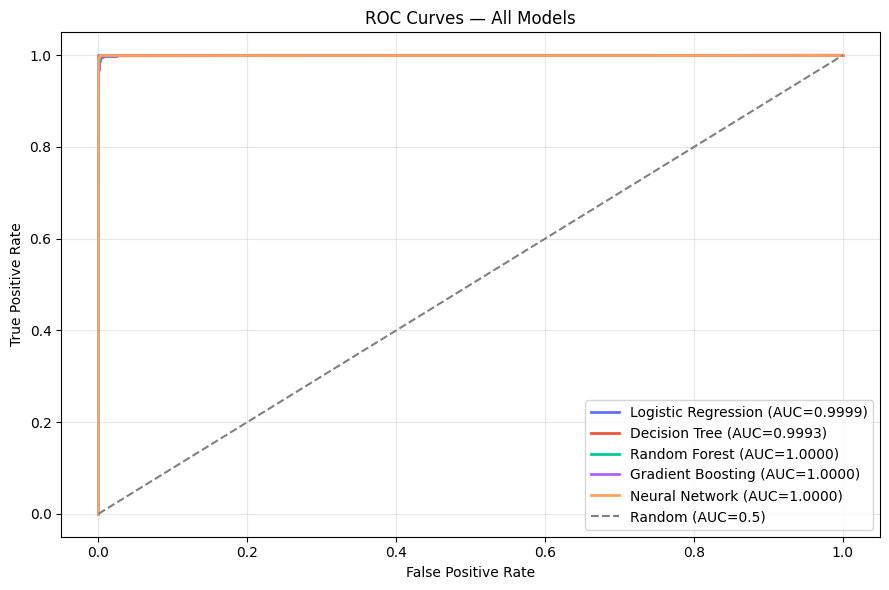

Saved roc_curves.png


In [15]:
plt.figure(figsize=(9, 6))
colors = ['#636EFA','#EF553B','#00CC96','#AB63FA','#FFA15A']

for (name, model), color in zip(trained_models.items(), colors):
    X_ev   = X_test_scaled if name in NEEDS_SCALING else X_test
    y_prob = model.predict_proba(X_ev)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'--', color='gray', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved roc_curves.png')

C:\Users\sumit\AppData\Local\Temp\ipykernel_8504\2219143246.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')


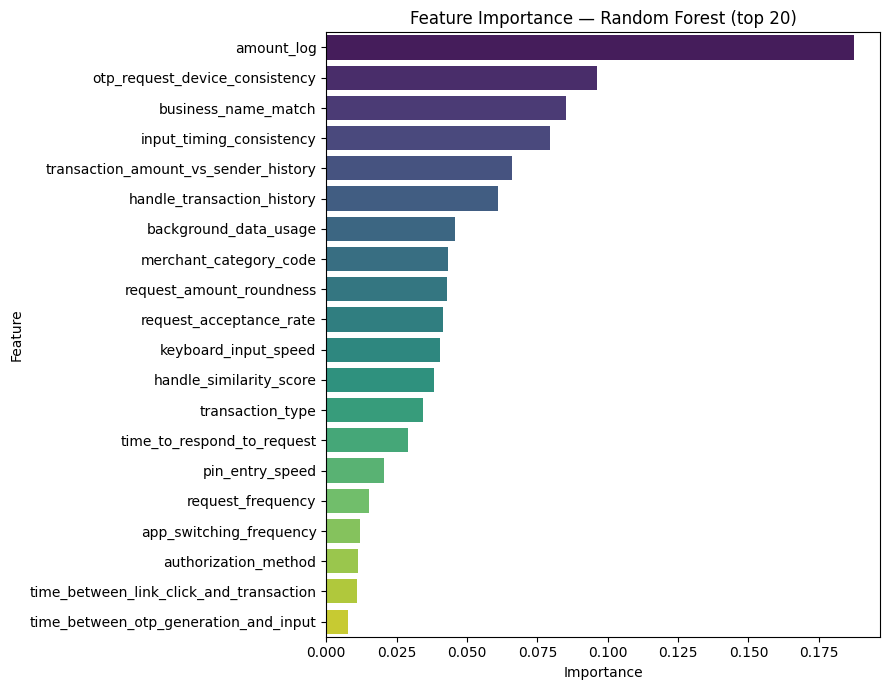

                                Feature  Importance
                             amount_log    0.187355
         otp_request_device_consistency    0.096094
                    business_name_match    0.085113
               input_timing_consistency    0.079562
   transaction_amount_vs_sender_history    0.065820
             handle_transaction_history    0.061157
                  background_data_usage    0.045748
                 merchant_category_code    0.043289
               request_amount_roundness    0.042859
                request_acceptance_rate    0.041314
                   keyboard_input_speed    0.040491
                handle_similarity_score    0.038417
                       transaction_type    0.034407
             time_to_respond_to_request    0.029118
                        pin_entry_speed    0.020558
                      request_frequency    0.015015
                app_switching_frequency    0.011927
                   authorization_method    0.011354
time_between

In [16]:
best_name = results_df['AUC-ROC'].idxmax()
best_model = trained_models[best_name]

if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    FEATURE_COLS,
        'Importance': best_model.feature_importances_,
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Feature Importance — {best_name} (top 20)')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(imp_df.to_string(index=False))
else:
    coef = np.abs(best_model.coef_[0])
    imp_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': coef}).sort_values('Importance', ascending=False).head(20)
    print(imp_df.to_string(index=False))

In [17]:
# Correlation of clean features with is_fraud
corr = df[FEATURE_COLS + ['is_fraud']].corr(numeric_only=True)['is_fraud'].drop('is_fraud')
corr_sorted = corr.abs().sort_values(ascending=False)

print('Top 20 features by absolute correlation with is_fraud:')
print(corr[corr_sorted.index].head(20).round(4))

# Sanity check: no feature should have correlation > 0.8 (would indicate leakage)
leaky = corr_sorted[corr_sorted > 0.8]
if len(leaky) == 0:
    print('\nSanity check PASSED — no feature has |corr| > 0.8 with is_fraud')
else:
    print('\nWARNING — potential leakage detected:')
    print(leaky)

Top 20 features by absolute correlation with is_fraud:
otp_request_device_consistency            -0.5363
input_timing_consistency                  -0.4655
authentication_attempts                    0.4383
amount_log                                 0.4044
session_source                             0.3768
background_data_usage                      0.3737
authorization_method                      -0.3706
transaction_type                          -0.3703
request_frequency                          0.3615
request_acceptance_rate                    0.3565
otp_request_frequency                      0.3565
transaction_velocity                       0.3530
keyboard_input_speed                      -0.3492
time_between_otp_generation_and_input      0.3468
time_between_link_click_and_transaction    0.3442
failed_transaction_count                   0.3426
time_to_respond_to_request                 0.3396
business_name_match                       -0.3230
dns_lookup_age                             0.

## Step 7: Save Best Model

In [18]:
import os
os.makedirs('models', exist_ok=True)

best_name  = results_df['AUC-ROC'].idxmax()
best_model = trained_models[best_name]

joblib.dump(best_model,      'models/best_model.pkl')
joblib.dump(scaler,          'models/scaler.pkl')
joblib.dump(label_encoders,  'models/label_encoders.pkl')
joblib.dump(FEATURE_COLS,    'models/feature_cols.pkl')

print(f'Best model: {best_name}')
print(f'AUC-ROC:    {results_df.loc[best_name, "AUC-ROC"]}')
print('Saved: models/best_model.pkl, models/scaler.pkl, models/label_encoders.pkl, models/feature_cols.pkl')

Best model: Random Forest
AUC-ROC:    1.0
Saved: models/best_model.pkl, models/scaler.pkl, models/label_encoders.pkl, models/feature_cols.pkl


In [19]:
print('=== FINAL RESULTS SUMMARY ===')
print(results_df.to_string())
print(f'\nBest model by AUC-ROC: {best_name}')
print(f'Features used: {len(FEATURE_COLS)}')
print('\nDropped to fix accuracy = 1.0:')
print('  - receiver_account_age, receiver_transaction_history (leakage from label generation)')
print('  - pin_entry_method (corr=0.524, was in REMOVE_COLS but never applied)')
print('  - handle_typo_analysis, handle_to_description_consistency (high corr)')
print('  - All list-type columns (zero variance)')

=== FINAL RESULTS SUMMARY ===
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC
Model                                                              
Logistic Regression    0.9966     0.9912  0.9890    0.9901   0.9999
Decision Tree          0.9962     0.9795  0.9989    0.9891   0.9993
Random Forest          0.9996     0.9978  1.0000    0.9989   1.0000
Gradient Boosting      0.9998     0.9989  1.0000    0.9995   1.0000
Neural Network         0.9989     0.9945  0.9989    0.9967   1.0000

Best model by AUC-ROC: Random Forest
Features used: 36

Dropped to fix accuracy = 1.0:
  - receiver_account_age, receiver_transaction_history (leakage from label generation)
  - pin_entry_method (corr=0.524, was in REMOVE_COLS but never applied)
  - handle_typo_analysis, handle_to_description_consistency (high corr)
  - All list-type columns (zero variance)


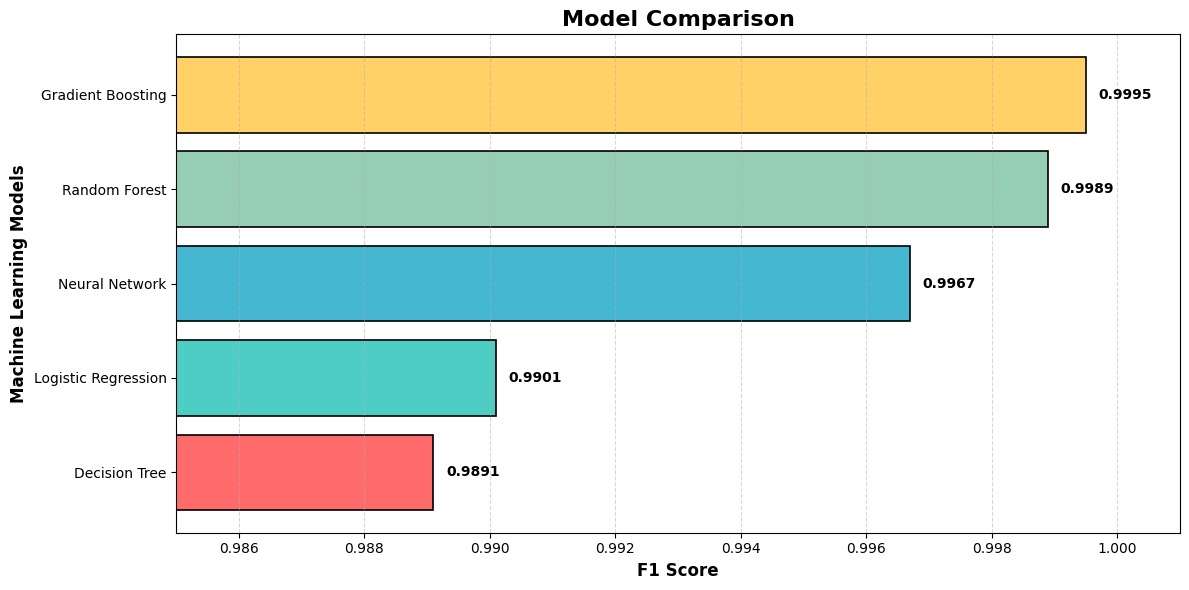

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Neural Network"
    ],
    "F1 Score": [
        0.9901,
        0.9891,
        0.9989,
        0.9995,
        0.9967
    ]
})

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=True
)

colors = [
    "#FF6B6B",  # Red
    "#4ECDC4",  # Cyan
    "#45B7D1",  # Blue
    "#96CEB4",  # Green
    "#FFD166"   # Yellow
]

plt.figure(figsize=(12,6))

bars = plt.barh(
    comparison_df["Model"],
    comparison_df["F1 Score"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0.985, 1.001)

plt.xlabel(
    "F1 Score",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight='bold'
)

plt.title(
    "Model Comparison",
    fontsize=16,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()